In [1]:
import os
import sys
import argparse
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as geopd
import matplotlib.pyplot as plt
import subprocess

## Config

In [2]:
DIR = "/home/dy23a.fsu/st/datasets/raw"
DIR = os.path.join(DIR, "NYC")
TAXI_DIR = Path(DIR) / "taxi"
BIKE_DIR = Path(DIR) / "bike"

# OD trips are binned by a single timestamp. As in the flow notebook, FLOW_MODE
# selects which leg's time stamps the trip:
#   departure -> pickup/start time   (when the trip leaves the origin)
#   arrival   -> dropoff/end time    (when the trip reaches the destination)
# The origin (O) and destination (D) regions are always taken from the
# pickup and dropoff locations respectively, regardless of FLOW_MODE.
FLOW_MODE = "departure"  # departure -> pickup/start ; arrival -> dropoff/end
assert FLOW_MODE in {"arrival", "departure"}

ZONES_PATH = "./NYC Taxi Zones.geojson"

OUT_DIR = Path(DIR)

TARGET_BOROUGH = "Manhattan"  # Manhattan / All

In [3]:
YEAR = 2025
FREQ = "15min"
TIME_START = pd.Timestamp(f"{YEAR}-01-01 00:00:00")
TIME_END = pd.Timestamp(f"{YEAR + 1}-01-01 00:00:00")
STEPS = pd.date_range(TIME_START, TIME_END, freq=FREQ, inclusive="left")
T = len(STEPS)
FREQ_TAG = FREQ
print(f"YEAR={YEAR}, FREQ={FREQ}, T={T} steps, FLOW_MODE={FLOW_MODE}")

YEAR=2025, FREQ=15min, T=35040 steps, FLOW_MODE=departure


## Shapefile, region selection, and helpers

Region order follows the shapefile (sorted by `LocationID`). Unlike the flow
notebook -- which builds full-city `(N, T)` arrays and filters afterwards -- an
OD matrix is `N x N` per step, so the full city would need
`263 x 263 x T` cells (~19 GB per mobility). We therefore restrict to the
selected regions (`TARGET_BOROUGH`) **up front** and accumulate directly into a
compact `(n, n, T)` matrix, where `n = len(sel_idx)`.

`region_to_local` maps a full shapefile `region_idx` to its position in the
selected subset (or `-1` if dropped). All output `(n, n, M, T)` arrays use the
selected-region order (origin axis first, destination axis second).

In [4]:
zones = geopd.read_file(ZONES_PATH).to_crs("EPSG:4326")
zones = zones.sort_values("LocationID").reset_index(drop=True)
zones["region_idx"] = np.arange(len(zones), dtype=np.int32)
zones_for_join = zones[["region_idx", "geometry"]]
N = len(zones)
bounds = zones.total_bounds
locationid_to_region = {int(loc): idx for idx, loc in enumerate(zones["LocationID"].tolist()) if pd.notna(loc)}
print(f"N={N} regions, bbox={bounds}")

# ── Region selection (origin == destination region set) ──────────────────
if TARGET_BOROUGH and str(TARGET_BOROUGH).lower() != "all":
    mask = zones["borough"].astype(str).str.lower() == TARGET_BOROUGH.lower()
    sel_idx = np.where(mask.to_numpy())[0]
    if sel_idx.size == 0:
        raise ValueError(f"No zones found for borough={TARGET_BOROUGH}")
    borough_tag = TARGET_BOROUGH.lower().replace(" ", "_")
else:
    sel_idx = np.arange(N)
    borough_tag = "all"

zones_sel = zones.iloc[sel_idx].reset_index(drop=True)
n_sel = len(sel_idx)
region_to_local = np.full(N, -1, dtype=np.int32)
region_to_local[sel_idx] = np.arange(n_sel, dtype=np.int32)
print(f"TARGET_BOROUGH={TARGET_BOROUGH}, selected {n_sel}/{N} regions, "
      f"OD matrix per step = {n_sel} x {n_sel}")

N=263 regions, bbox=[-74.25559136  40.4961154  -73.70000906  40.91553278]
TARGET_BOROUGH=Manhattan, selected 69/263 regions, OD matrix per step = 69 x 69


In [5]:
def timestamps_to_step_idx(ts_series):
    ts = pd.to_datetime(ts_series, errors="coerce")
    step = ts.dt.floor(FREQ)
    delta_minutes = (step - TIME_START) / pd.Timedelta(FREQ)
    idx_float = delta_minutes.to_numpy(dtype=np.float64)
    valid = np.isfinite(idx_float) & (idx_float >= 0) & (idx_float < T)
    step_idx = np.zeros(len(idx_float), dtype=np.int64)
    step_idx[valid] = idx_float[valid].astype(np.int64)
    return step_idx, valid

def map_points_to_regions(lon_arr, lat_arr, join_gdf, bounds_):
    minx, miny, maxx, maxy = bounds_
    region_idx = np.full(len(lon_arr), -1, dtype=np.int32)
    in_bbox = (
        (lon_arr >= minx)
        & (lon_arr <= maxx)
        & (lat_arr >= miny)
        & (lat_arr <= maxy)
    )
    if not np.any(in_bbox):
        return region_idx
    candidate_ids = np.where(in_bbox)[0]
    pts = geopd.GeoDataFrame(
        {"row_id": candidate_ids},
        geometry=geopd.points_from_xy(lon_arr[in_bbox], lat_arr[in_bbox]),
        crs="EPSG:4326",
    )
    joined = geopd.sjoin(pts, join_gdf, how="left", predicate="intersects")
    matched = joined.dropna(subset=["region_idx"]).drop_duplicates(subset=["row_id"], keep="first")
    region_idx[matched["row_id"].to_numpy(dtype=np.int64)] = matched["region_idx"].to_numpy(dtype=np.int32)
    return region_idx

def accumulate_od(o_local, d_local, step_idx, time_valid, od_matrix):
    """Bin trips into an (n, n, T) origin-destination matrix (in-place).

    o_local / d_local are local region indices (0..n-1, or -1 to drop).
    A trip is kept only when both endpoints fall inside the selected set.
    """
    n = od_matrix.shape[0]
    T_ = od_matrix.shape[2]
    valid = time_valid & (o_local >= 0) & (d_local >= 0)
    if not np.any(valid):
        return 0
    flat_idx = (
        (o_local[valid].astype(np.int64) * n + d_local[valid].astype(np.int64)) * T_
        + step_idx[valid].astype(np.int64)
    )
    binc = np.bincount(flat_idx, minlength=n * n * T_)
    od_matrix += binc.reshape(n, n, T_)
    return int(valid.sum())

## Taxi OD (yellow + green merged)

Both yellow and green carry `PULocationID` / `DOLocationID`, mapped to
`region_idx` via the shapefile's `LocationID`, then to the selected-region
local index. `FLOW_MODE` chooses the binning timestamp (pickup vs. dropoff).

In [6]:
def process_taxi_od_parquet(files, schema_map):
    """schema_map: {pattern_prefix: {'pu_id','do_id','pu_time','do_time'}}."""
    import pyarrow.parquet as pq
    od = np.zeros((n_sel, n_sel, T), dtype=np.int64)
    total_rows = 0
    kept_rows = 0
    for fp in files:
        prefix = next((k for k in schema_map if fp.name.startswith(k)), None)
        if prefix is None:
            print(f"  skip (no schema): {fp.name}")
            continue
        cols = schema_map[prefix]
        time_col = cols["do_time"] if FLOW_MODE == "arrival" else cols["pu_time"]
        pu_col, do_col = cols["pu_id"], cols["do_id"]
        print(f"Processing {fp.name} [O={pu_col}, D={do_col}, t={time_col}]")
        pq_file = pq.ParquetFile(fp)
        for rg in range(pq_file.num_row_groups):
            table = pq_file.read_row_group(rg, columns=[pu_col, do_col, time_col])
            df = table.to_pandas()
            total_rows += len(df)
            df = df.dropna(subset=[pu_col, do_col, time_col])
            if df.empty:
                continue
            pu = pd.to_numeric(df[pu_col], errors="coerce")
            do = pd.to_numeric(df[do_col], errors="coerce")
            valid_loc = pu.notna() & do.notna()
            if not valid_loc.any():
                continue
            pu = pu[valid_loc].astype(np.int64).reset_index(drop=True)
            do = do[valid_loc].astype(np.int64).reset_index(drop=True)
            ts = df.loc[valid_loc, time_col].reset_index(drop=True)
            o_region = pu.map(locationid_to_region).fillna(-1).to_numpy(dtype=np.int64)
            d_region = do.map(locationid_to_region).fillna(-1).to_numpy(dtype=np.int64)
            o_local = np.where(o_region >= 0, region_to_local[o_region.clip(min=0)], -1).astype(np.int32)
            d_local = np.where(d_region >= 0, region_to_local[d_region.clip(min=0)], -1).astype(np.int32)
            step_idx, time_valid = timestamps_to_step_idx(ts)
            kept_rows += accumulate_od(o_local, d_local, step_idx, time_valid, od)
    print(f"Rows seen: {total_rows:,}, kept in OD: {kept_rows:,}")
    return od

In [7]:
taxi_schema = {
    "yellow_tripdata": {
        "pu_id": "PULocationID",
        "do_id": "DOLocationID",
        "pu_time": "tpep_pickup_datetime",
        "do_time": "tpep_dropoff_datetime",
    },
    "green_tripdata": {
        "pu_id": "PULocationID",
        "do_id": "DOLocationID",
        "pu_time": "lpep_pickup_datetime",
        "do_time": "lpep_dropoff_datetime",
    },
}
taxi_files = sorted(
    [p for p in TAXI_DIR.glob(f"yellow_tripdata_{YEAR}-*.parquet")] +
    [p for p in TAXI_DIR.glob(f"green_tripdata_{YEAR}-*.parquet")]
)
if not taxi_files:
    raise FileNotFoundError(f"No yellow/green taxi parquet files found under {TAXI_DIR}")
nyc_taxi_od = process_taxi_od_parquet(taxi_files, taxi_schema)
taxi_out = OUT_DIR / f"nyc_{borough_tag}_taxi_od_{YEAR}_{FREQ_TAG}.npy"
np.save(taxi_out, nyc_taxi_od)
print(f"Saved {taxi_out} shape={nyc_taxi_od.shape} (O,D,T), total={nyc_taxi_od.sum():,}")

Processing green_tripdata_2025-01.parquet [O=PULocationID, D=DOLocationID, t=lpep_pickup_datetime]
Processing green_tripdata_2025-02.parquet [O=PULocationID, D=DOLocationID, t=lpep_pickup_datetime]
Processing green_tripdata_2025-03.parquet [O=PULocationID, D=DOLocationID, t=lpep_pickup_datetime]
Processing green_tripdata_2025-04.parquet [O=PULocationID, D=DOLocationID, t=lpep_pickup_datetime]
Processing green_tripdata_2025-05.parquet [O=PULocationID, D=DOLocationID, t=lpep_pickup_datetime]
Processing green_tripdata_2025-06.parquet [O=PULocationID, D=DOLocationID, t=lpep_pickup_datetime]
Processing green_tripdata_2025-07.parquet [O=PULocationID, D=DOLocationID, t=lpep_pickup_datetime]
Processing green_tripdata_2025-08.parquet [O=PULocationID, D=DOLocationID, t=lpep_pickup_datetime]
Processing green_tripdata_2025-09.parquet [O=PULocationID, D=DOLocationID, t=lpep_pickup_datetime]
Processing green_tripdata_2025-10.parquet [O=PULocationID, D=DOLocationID, t=lpep_pickup_datetime]
Processing

## FHV OD (fhv + fhvhv merged)

`fhv` parquet uses lower-case `PUlocationID` / `DOlocationID` and
`dropOff_datetime`; `fhvhv` uses `PULocationID` / `DOLocationID`. Longer prefix
is matched first so `fhv_tripdata` does not shadow `fhvhv_tripdata`.

In [8]:
fhv_schema = {
    "fhvhv_tripdata": {
        "pu_id": "PULocationID",
        "do_id": "DOLocationID",
        "pu_time": "pickup_datetime",
        "do_time": "dropoff_datetime",
    },
    "fhv_tripdata": {
        "pu_id": "PUlocationID",
        "do_id": "DOlocationID",
        "pu_time": "pickup_datetime",
        "do_time": "dropOff_datetime",
    },
}
fhv_schema_ordered = {k: fhv_schema[k] for k in sorted(fhv_schema, key=len, reverse=True)}
fhv_files = sorted(
    [p for p in TAXI_DIR.glob(f"fhvhv_tripdata_{YEAR}-*.parquet")] +
    [p for p in TAXI_DIR.glob(f"fhv_tripdata_{YEAR}-*.parquet")]
)
if not fhv_files:
    raise FileNotFoundError(f"No fhv/fhvhv parquet files found under {TAXI_DIR}")
nyc_fhv_od = process_taxi_od_parquet(fhv_files, fhv_schema_ordered)
fhv_out = OUT_DIR / f"nyc_{borough_tag}_fhv_od_{YEAR}_{FREQ_TAG}.npy"
np.save(fhv_out, nyc_fhv_od)
print(f"Saved {fhv_out} shape={nyc_fhv_od.shape} (O,D,T), total={nyc_fhv_od.sum():,}")

Processing fhv_tripdata_2025-01.parquet [O=PUlocationID, D=DOlocationID, t=pickup_datetime]
Processing fhv_tripdata_2025-02.parquet [O=PUlocationID, D=DOlocationID, t=pickup_datetime]
Processing fhv_tripdata_2025-03.parquet [O=PUlocationID, D=DOlocationID, t=pickup_datetime]
Processing fhv_tripdata_2025-04.parquet [O=PUlocationID, D=DOlocationID, t=pickup_datetime]
Processing fhv_tripdata_2025-05.parquet [O=PUlocationID, D=DOlocationID, t=pickup_datetime]
Processing fhv_tripdata_2025-06.parquet [O=PUlocationID, D=DOlocationID, t=pickup_datetime]
Processing fhv_tripdata_2025-07.parquet [O=PUlocationID, D=DOlocationID, t=pickup_datetime]
Processing fhv_tripdata_2025-08.parquet [O=PUlocationID, D=DOlocationID, t=pickup_datetime]
Processing fhv_tripdata_2025-09.parquet [O=PUlocationID, D=DOlocationID, t=pickup_datetime]
Processing fhv_tripdata_2025-10.parquet [O=PUlocationID, D=DOlocationID, t=pickup_datetime]
Processing fhv_tripdata_2025-11.parquet [O=PUlocationID, D=DOlocationID, t=picku

## Bike OD (gps -> shapefile)

Citi Bike CSVs only carry lat/lon, so both the start and end points are
spatially joined to a Taxi Zone polygon, then mapped to the local index.

In [9]:
def process_bike_od_csv(files, chunksize=500_000):
    od = np.zeros((n_sel, n_sel, T), dtype=np.int64)
    total_rows = 0
    kept_rows = 0
    time_col = "ended_at" if FLOW_MODE == "arrival" else "started_at"
    usecols = ["start_lng", "start_lat", "end_lng", "end_lat", time_col]
    for fp in files:
        print(f"Processing {fp.name}")
        reader = pd.read_csv(fp, usecols=usecols, chunksize=chunksize, low_memory=False)
        for chunk in reader:
            total_rows += len(chunk)
            chunk = chunk.dropna(subset=usecols)
            if chunk.empty:
                continue
            o_lon = pd.to_numeric(chunk["start_lng"], errors="coerce").to_numpy(dtype=np.float64)
            o_lat = pd.to_numeric(chunk["start_lat"], errors="coerce").to_numpy(dtype=np.float64)
            d_lon = pd.to_numeric(chunk["end_lng"], errors="coerce").to_numpy(dtype=np.float64)
            d_lat = pd.to_numeric(chunk["end_lat"], errors="coerce").to_numpy(dtype=np.float64)
            valid_xy = (
                np.isfinite(o_lon) & np.isfinite(o_lat)
                & np.isfinite(d_lon) & np.isfinite(d_lat)
            )
            if not np.any(valid_xy):
                continue
            o_lon, o_lat = o_lon[valid_xy], o_lat[valid_xy]
            d_lon, d_lat = d_lon[valid_xy], d_lat[valid_xy]
            ts = chunk.loc[valid_xy, time_col].reset_index(drop=True)
            o_region = map_points_to_regions(o_lon, o_lat, zones_for_join, bounds)
            d_region = map_points_to_regions(d_lon, d_lat, zones_for_join, bounds)
            o_local = np.where(o_region >= 0, region_to_local[o_region.clip(min=0)], -1).astype(np.int32)
            d_local = np.where(d_region >= 0, region_to_local[d_region.clip(min=0)], -1).astype(np.int32)
            step_idx, time_valid = timestamps_to_step_idx(ts)
            kept_rows += accumulate_od(o_local, d_local, step_idx, time_valid, od)
    print(f"Rows seen: {total_rows:,}, kept in OD: {kept_rows:,}")
    return od

bike_files = sorted(BIKE_DIR.glob(f"{YEAR}??-citibike-tripdata*.csv"))
if not bike_files:
    raise FileNotFoundError(f"No bike CSV files found under {BIKE_DIR}")
nyc_bike_od = process_bike_od_csv(bike_files)
bike_out = OUT_DIR / f"nyc_{borough_tag}_bike_od_{YEAR}_{FREQ_TAG}.npy"
np.save(bike_out, nyc_bike_od)
print(f"Saved {bike_out} shape={nyc_bike_od.shape} (O,D,T), total={nyc_bike_od.sum():,}")

Processing 202501-citibike-tripdata_1.csv
Processing 202501-citibike-tripdata_2.csv
Processing 202501-citibike-tripdata_3.csv
Processing 202502-citibike-tripdata_1.csv
Processing 202502-citibike-tripdata_2.csv
Processing 202502-citibike-tripdata_3.csv
Processing 202503-citibike-tripdata_1.csv
Processing 202503-citibike-tripdata_2.csv
Processing 202503-citibike-tripdata_3.csv
Processing 202503-citibike-tripdata_4.csv
Processing 202504-citibike-tripdata_1.csv
Processing 202504-citibike-tripdata_2.csv
Processing 202504-citibike-tripdata_3.csv
Processing 202504-citibike-tripdata_4.csv
Processing 202505-citibike-tripdata_1.csv
Processing 202505-citibike-tripdata_2.csv
Processing 202505-citibike-tripdata_3.csv
Processing 202505-citibike-tripdata_4.csv
Processing 202505-citibike-tripdata_5.csv
Processing 202506-citibike-tripdata_1.csv
Processing 202506-citibike-tripdata_2.csv
Processing 202506-citibike-tripdata_3.csv
Processing 202506-citibike-tripdata_4.csv
Processing 202506-citibike-tripdat

## Summary

In [10]:
def summarize_od(name, arr):
    arr = np.asarray(arr)
    total = float(arr.sum())
    nnz = int(np.count_nonzero(arr))
    density = 100.0 * nnz / arr.size if arr.size else 0.0
    pair_flow = arr.sum(axis=2)                      # (O, D) total over time
    active_pairs = int((pair_flow > 0).sum())
    active_o = int((arr.sum(axis=(1, 2)) > 0).sum())
    active_d = int((arr.sum(axis=(0, 2)) > 0).sum())
    active_steps = int((arr.sum(axis=(0, 1)) > 0).sum())
    print(f"[{name}] shape={arr.shape}, total={total:,.0f}, nnz={nnz:,} ({density:.3f}%), "
          f"active_pairs={active_pairs}/{arr.shape[0] * arr.shape[1]}, "
          f"active_O={active_o}/{arr.shape[0]}, active_D={active_d}/{arr.shape[1]}, "
          f"active_steps={active_steps}/{arr.shape[2]}")

for name, arr in [("taxi", nyc_taxi_od), ("fhv", nyc_fhv_od), ("bike", nyc_bike_od)]:
    summarize_od(name, arr)

[taxi] shape=(69, 69, 35040), total=39,399,802, nnz=23,096,738 (13.845%), active_pairs=4353/4761, active_O=67/69, active_D=67/69, active_steps=35036/35040
[fhv] shape=(69, 69, 35040), total=61,308,921, nnz=35,622,485 (21.353%), active_pairs=4401/4761, active_O=68/69, active_D=69/69, active_steps=35037/35040
[bike] shape=(69, 69, 35040), total=26,997,792, nnz=15,181,055 (9.100%), active_pairs=4345/4761, active_O=67/69, active_D=67/69, active_steps=35031/35040


## Merge mobilities -> (N, N, M, T)

Stack any subset of `["taxi", "fhv", "bike"]` along a new mobility axis to get
the final `(N, N, M, T)` tensor (origin, destination, mobility, time), where
`N = n_sel`.

In [11]:
MERGE_MOBILITIES = ["taxi", "fhv", "bike"]
MOBILITY_ARRS = {"taxi": nyc_taxi_od, "fhv": nyc_fhv_od, "bike": nyc_bike_od}
missing = [m for m in MERGE_MOBILITIES if m not in MOBILITY_ARRS]
if missing:
    raise ValueError(f"Unknown mobilities in MERGE_MOBILITIES: {missing}")

# (O, D, T) per mobility -> stack on axis=2 -> (N, N, M, T)
merged = np.stack([MOBILITY_ARRS[m] for m in MERGE_MOBILITIES], axis=2)
merged_tag = "_".join(MERGE_MOBILITIES)
M_dim = len(MERGE_MOBILITIES)
merged_out = OUT_DIR / f"nyc_{borough_tag}_{merged_tag}_od_{YEAR}_{FREQ_TAG}.npy"
np.save(merged_out, merged)
print(f"{merged_out} shape={merged.shape} (N, N, M, T) with M={M_dim} mobilities")

/home/dy23a.fsu/st/datasets/raw/NYC/nyc_manhattan_taxi_fhv_bike_od_2025_15min.npy shape=(69, 69, 3, 35040) (N, N, M, T) with M=3 mobilities


## Visualization & Sparsity Report

For each mobility (`taxi`, `fhv`, `bike`):
- **OD heatmap**: log1p total origin-destination flow `(O x D)` over the whole
  year.
- **Origin/destination choropleth**: total outflow / inflow per region painted
  on the selected Taxi Zones.
- **Temporal panels**: daily total OD flow and the weekday x hour-of-day
  occupancy.
- **Sparsity report**: zero-rate over `(O, D, T)`, dead pairs / origins /
  destinations / steps, and per-pair / per-step quantiles.

In [12]:
MOBILITY_ARRS_VIZ = {"taxi": nyc_taxi_od, "fhv": nyc_fhv_od, "bike": nyc_bike_od}

def plot_od_heat(arr, title):
    pair = np.asarray(arr).sum(axis=2)              # (O, D)
    fig, ax = plt.subplots(1, 1, figsize=(7, 6))
    im = ax.imshow(np.log1p(pair), aspect="auto", cmap="magma", origin="upper")
    ax.set_title(title)
    ax.set_xlabel("Destination region (local idx)")
    ax.set_ylabel("Origin region (local idx)")
    fig.colorbar(im, ax=ax, shrink=0.8, label="log1p(total flow)")
    plt.tight_layout()
    plt.show()

def plot_zone_heat(zone_gdf, values, title, cmap="YlOrRd", log=True):
    plot_gdf = zone_gdf.copy()
    vals = np.asarray(values, dtype=np.float64)
    plot_gdf["flow"] = np.log1p(vals) if log else vals
    legend_label = "log1p(total flow)" if log else "total flow"
    fig, ax = plt.subplots(1, 1, figsize=(8, 8))
    plot_gdf.plot(column="flow", cmap=cmap, linewidth=0.2, edgecolor="black",
                  legend=True, legend_kwds={"label": legend_label, "shrink": 0.6}, ax=ax)
    ax.set_title(title)
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()

def sparsity_report(name, arr, time_index):
    arr = np.asarray(arr)
    total_cells = arr.size
    nnz = int(np.count_nonzero(arr))
    zero_rate = 1.0 - nnz / total_cells if total_cells else 0.0
    total_flow = float(arr.sum())
    pair_sum = arr.sum(axis=2).reshape(-1)
    step_sum = arr.sum(axis=(0, 1))
    dead_pairs = int((pair_sum == 0).sum())
    dead_steps = int((step_sum == 0).sum())
    pair_q = np.quantile(pair_sum, [0.0, 0.25, 0.5, 0.75, 1.0])
    step_q = np.quantile(step_sum, [0.0, 0.25, 0.5, 0.75, 1.0])
    nz_pair_q = np.quantile(pair_sum[pair_sum > 0], [0.25, 0.5, 0.75]) if (pair_sum > 0).any() else np.array([0, 0, 0])
    print(f"=== Sparsity report: {name} ===")
    print(f"  shape={arr.shape}, total_flow={total_flow:,.0f}")
    print(f"  nnz cells={nnz:,}/{total_cells:,}  zero_rate={zero_rate*100:.3f}%")
    print(f"  dead pairs={dead_pairs}/{pair_sum.size}  dead steps={dead_steps}/{arr.shape[2]}")
    print(f"  pair totals  min/Q1/med/Q3/max = {pair_q[0]:,.0f} / {pair_q[1]:,.0f} / {pair_q[2]:,.0f} / {pair_q[3]:,.0f} / {pair_q[4]:,.0f}")
    print(f"  pair totals  (non-zero only) Q1/med/Q3 = {nz_pair_q[0]:,.0f} / {nz_pair_q[1]:,.0f} / {nz_pair_q[2]:,.0f}")
    print(f"  step totals  min/Q1/med/Q3/max = {step_q[0]:,.0f} / {step_q[1]:,.0f} / {step_q[2]:,.0f} / {step_q[3]:,.0f} / {step_q[4]:,.0f}")
    idx_active = np.where(step_sum > 0)[0]
    if idx_active.size:
        print(f"  first_active={pd.Timestamp(time_index[idx_active[0]])}, last_active={pd.Timestamp(time_index[idx_active[-1]])}")

def plot_temporal_panels(name, arr, time_index):
    arr = np.asarray(arr)
    ts = pd.to_datetime(time_index)
    series = pd.Series(arr.sum(axis=(0, 1)), index=ts)
    daily = series.resample("D").sum()
    hod = pd.DataFrame({"flow": series.values}, index=ts)
    hod["dow"] = hod.index.dayofweek
    hod["hour"] = hod.index.hour
    pivot = hod.pivot_table(index="dow", columns="hour", values="flow", aggfunc="sum").reindex(index=range(7), columns=range(24))
    fig, axes = plt.subplots(1, 2, figsize=(15, 4))
    axes[0].plot(daily.index, daily.values, linewidth=1.2)
    axes[0].set_title(f"{name} - daily total OD flow")
    axes[0].set_xlabel("Date")
    axes[0].set_ylabel("Daily total flow")
    axes[0].grid(alpha=0.25)
    im = axes[1].imshow(pivot.values, aspect="auto", cmap="viridis", origin="lower")
    axes[1].set_title(f"{name} - weekday x hour total OD flow")
    axes[1].set_xlabel("Hour of day")
    axes[1].set_ylabel("Day of week (0=Mon)")
    axes[1].set_xticks(range(0, 24, 3))
    axes[1].set_yticks(range(7))
    axes[1].set_yticklabels(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
    fig.colorbar(im, ax=axes[1], shrink=0.8, label="flow")
    plt.tight_layout()
    plt.show()

=== Sparsity report: taxi [Manhattan] ===
  shape=(69, 69, 35040), total_flow=39,399,802
  nnz cells=23,096,738/166,825,440  zero_rate=86.155%
  dead pairs=408/4761  dead steps=4/35040
  pair totals  min/Q1/med/Q3/max = 0 / 259 / 2,497 / 9,447 / 302,264
  pair totals  (non-zero only) Q1/med/Q3 = 634 / 3,140 / 10,841
  step totals  min/Q1/med/Q3/max = 0 / 466 / 1,249 / 1,602 / 3,485
  first_active=2025-01-01 00:00:00, last_active=2025-12-31 23:45:00


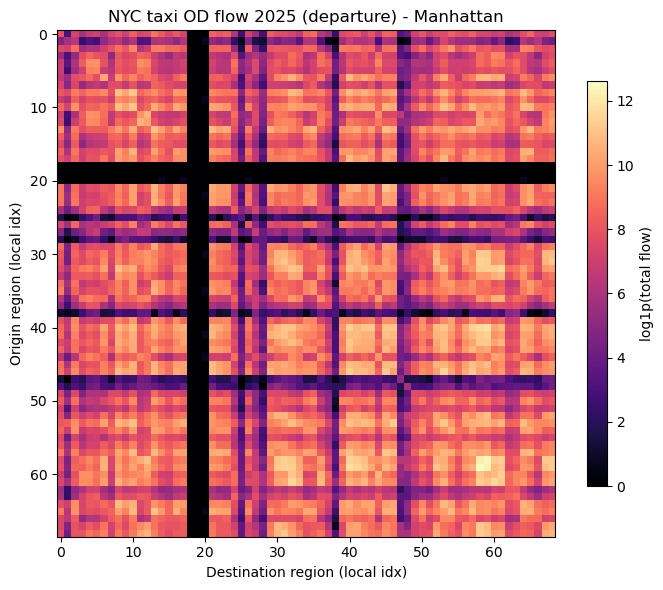

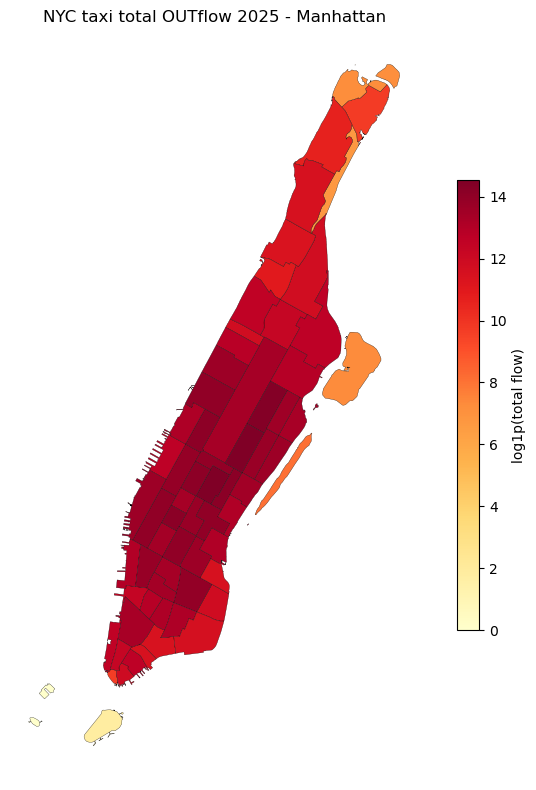

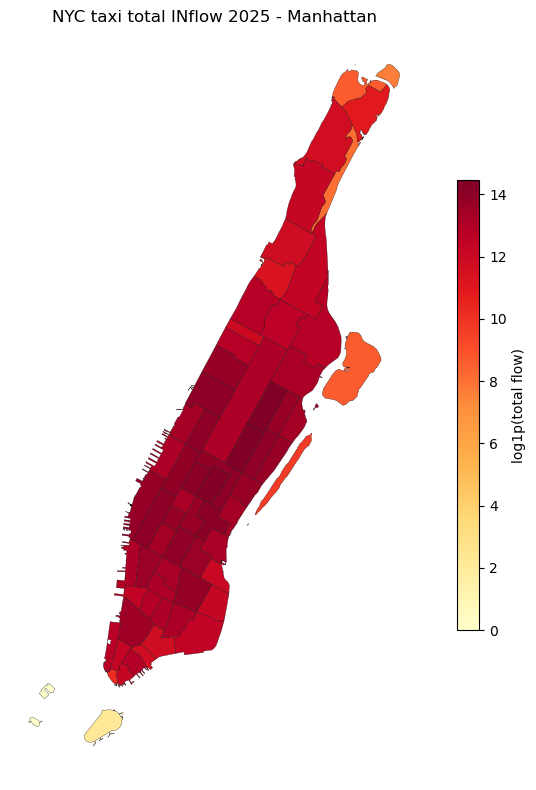

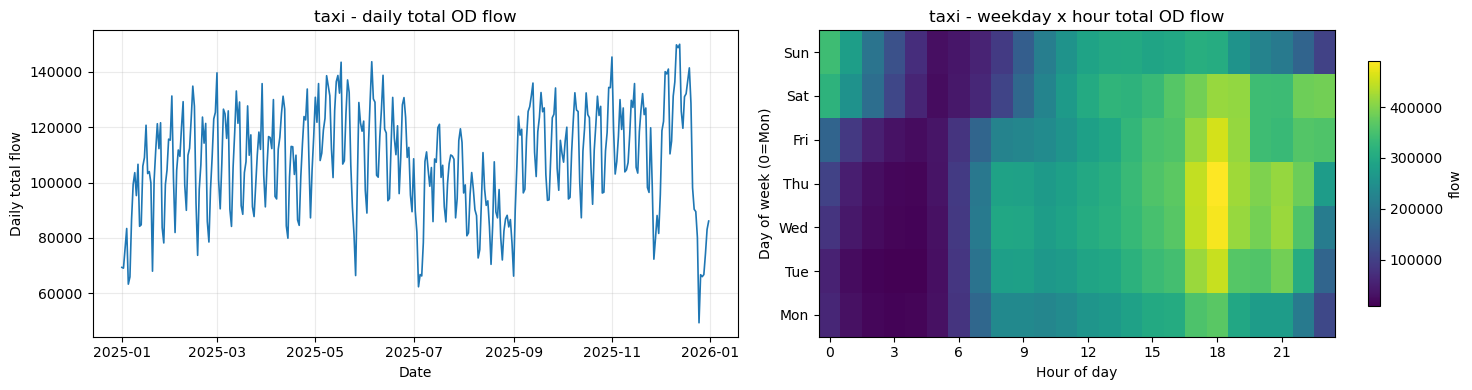

=== Sparsity report: fhv [Manhattan] ===
  shape=(69, 69, 35040), total_flow=61,308,921
  nnz cells=35,622,485/166,825,440  zero_rate=78.647%
  dead pairs=360/4761  dead steps=3/35040
  pair totals  min/Q1/med/Q3/max = 0 / 1,126 / 6,207 / 16,980 / 234,078
  pair totals  (non-zero only) Q1/med/Q3 = 1,920 / 7,325 / 18,348
  step totals  min/Q1/med/Q3/max = 0 / 998 / 1,869 / 2,359 / 5,485
  first_active=2025-01-01 00:00:00, last_active=2025-12-31 23:45:00


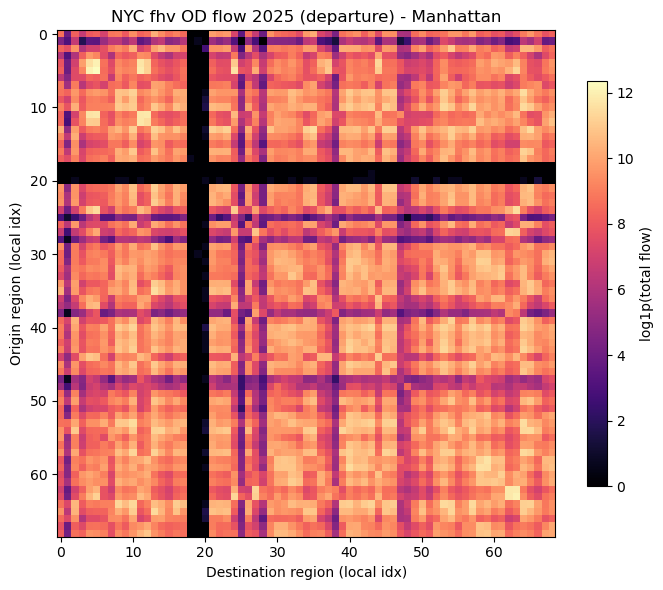

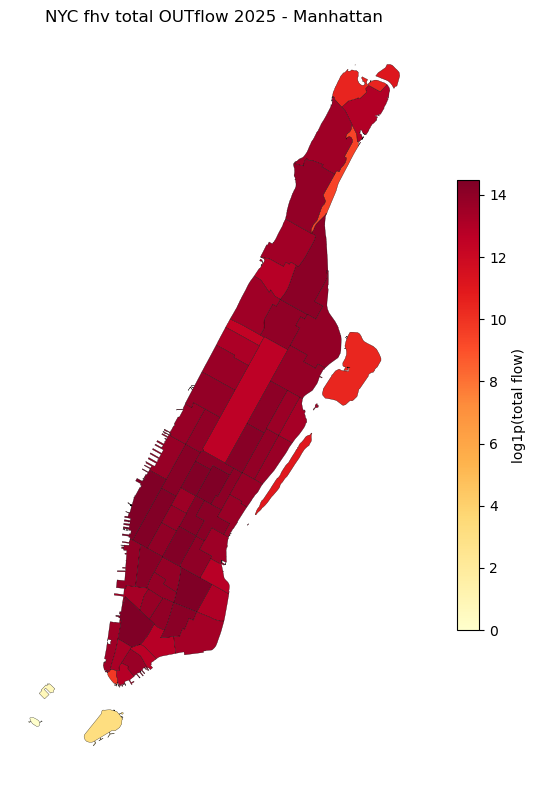

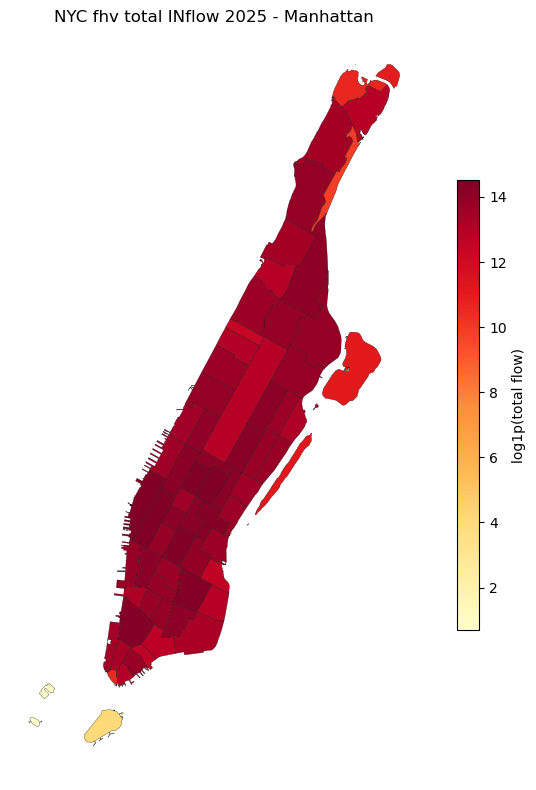

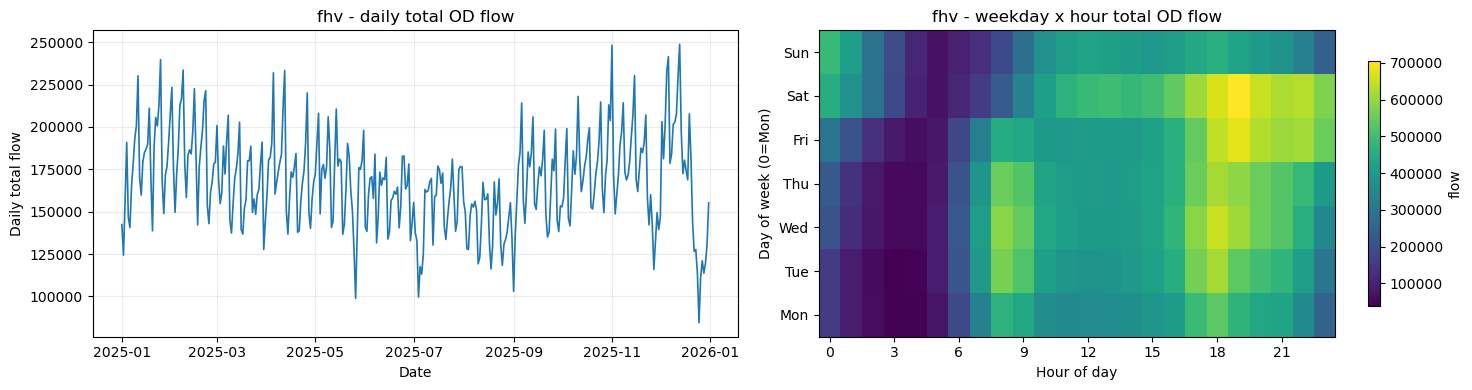

=== Sparsity report: bike [Manhattan] ===
  shape=(69, 69, 35040), total_flow=26,997,792
  nnz cells=15,181,055/166,825,440  zero_rate=90.900%
  dead pairs=416/4761  dead steps=9/35040
  pair totals  min/Q1/med/Q3/max = 0 / 73 / 907 / 5,296 / 417,519
  pair totals  (non-zero only) Q1/med/Q3 = 168 / 1,270 / 6,153
  step totals  min/Q1/med/Q3/max = 0 / 198 / 640 / 1,176 / 3,399
  first_active=2025-01-01 00:00:00, last_active=2025-12-31 23:45:00


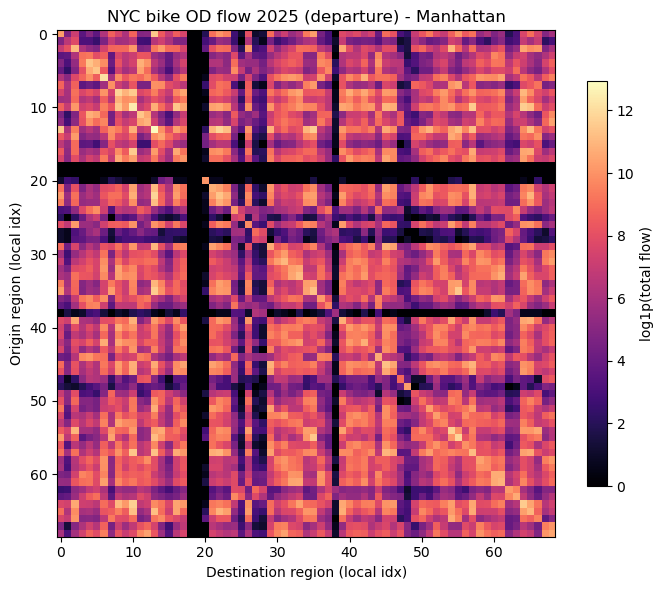

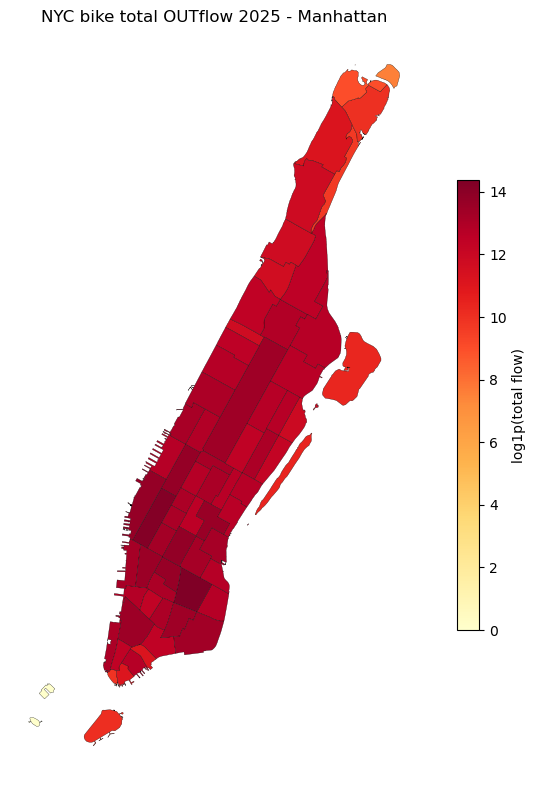

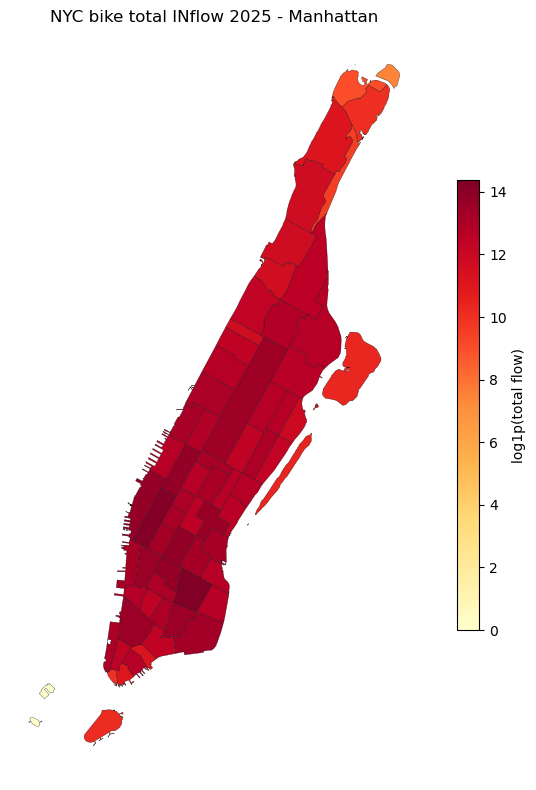

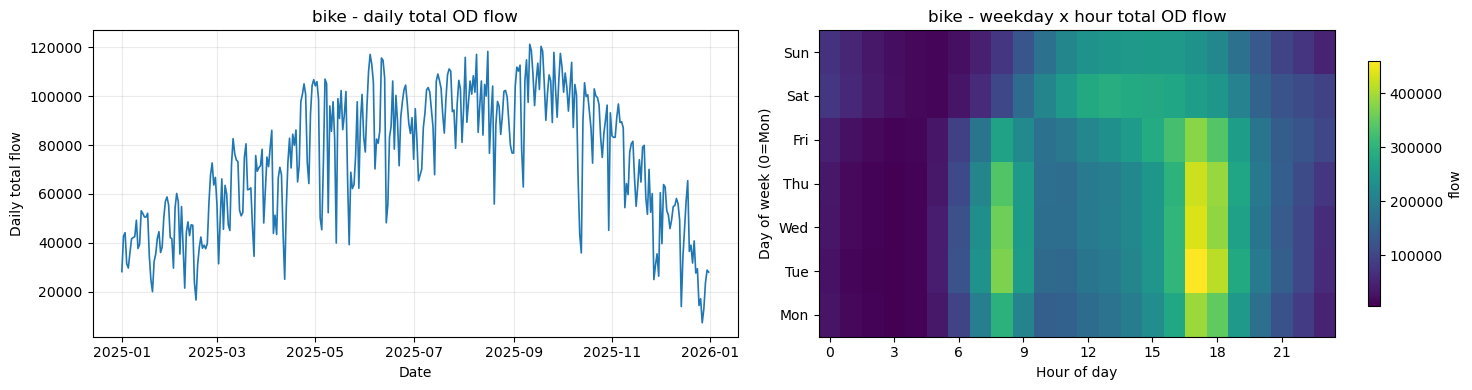

In [13]:
for name, arr in MOBILITY_ARRS_VIZ.items():
    sparsity_report(f"{name} [{TARGET_BOROUGH}]", arr, STEPS)
    plot_od_heat(arr, f"NYC {name} OD flow {YEAR} ({FLOW_MODE}) - {TARGET_BOROUGH}")
    plot_zone_heat(zones_sel, arr.sum(axis=(1, 2)), f"NYC {name} total OUTflow {YEAR} - {TARGET_BOROUGH}")
    plot_zone_heat(zones_sel, arr.sum(axis=(0, 2)), f"NYC {name} total INflow {YEAR} - {TARGET_BOROUGH}")
    plot_temporal_panels(name, arr, STEPS)

## Generate dataset (NNDT)

Feed the `(N, N, M, T)` tensor to `utils/generate.py` with `--fmt NNDT`
(origin, destination, mobility, time). The generator reorders to `(T, N, N, M)`,
fits a per-channel log1p MinMaxScaler over the `M` mobility channels, and writes
`his.npz` + `info.json` + `meta.json` + index files.

In [14]:
if TARGET_BOROUGH and str(TARGET_BOROUGH).lower() != "all":
    DATASET = "nyc_manhattan_od_15min"
else:
    DATASET = "nyc_od_15min"

src_path = OUT_DIR / f"nyc_{borough_tag}_{merged_tag}_od_{YEAR}_{FREQ_TAG}.npy"
print(f"Source {src_path} shape={tuple(np.load(src_path, mmap_mode='r').shape)} (N, N, M, T)")

subprocess.run([
    "python3", "/home/dy23a.fsu/st/utils/generate.py",
    "--data_path", str(src_path),
    "--fmt", "NNDT",
    "--clip_neg",
    "--per_channel",
    "--log1p",
    "--dataset", DATASET,
    "--years", str(YEAR),
    "--seq_length_x", "12",
    "--seq_length_y", "1",
], check=True)

Source /home/dy23a.fsu/st/datasets/raw/NYC/nyc_manhattan_taxi_fhv_bike_od_2025_15min.npy shape=(69, 69, 3, 35040) (N, N, M, T)
Loaded /home/dy23a.fsu/st/datasets/raw/NYC/nyc_manhattan_taxi_fhv_bike_od_2025_15min.npy, raw shape: (69, 69, 3, 35040)
Clipped negative values to 0
Reordered NNDT → TNND, shape: (35040, 69, 69, 3)
Raw — max: 108, min: 0, mean: 0.2552, std: 0.8258
Index range: [11, 35039), total=35028, train=28022, val=3503, test=3503
MinMaxScaler(log1p=True) min: [0.0, 0.0, 0.0], max: [3.97029185295105, 4.691348075866699, 4.382026672363281]
Normalized — max: 1.0000, min: 0.0000, mean: 0.0311, std: 0.0814
Saved meta.json to /blue/gtyson.fsu/dy23a.fsu/datasets/nyc_manhattan_od_15min/2025/meta.json
Saved to /blue/gtyson.fsu/dy23a.fsu/datasets/nyc_manhattan_od_15min/2025
Saved info.json to /blue/gtyson.fsu/dy23a.fsu/datasets/nyc_manhattan_od_15min/2025/info.json


CompletedProcess(args=['python3', '/home/dy23a.fsu/st/utils/generate.py', '--data_path', '/home/dy23a.fsu/st/datasets/raw/NYC/nyc_manhattan_taxi_fhv_bike_od_2025_15min.npy', '--fmt', 'NNDT', '--clip_neg', '--per_channel', '--log1p', '--dataset', 'nyc_manhattan_od_15min', '--years', '2025', '--seq_length_x', '12', '--seq_length_y', '1'], returncode=0)

## Adjacency

Distance-based adjacency over the selected region centroids, saved alongside
the OD dataset (mirrors the flow notebook).

In [15]:
sys.path.insert(0, "/home/dy23a.fsu/st/utils")
from get_adj_mat import get_adjacency_matrix

ADJ_DIR = Path("/home/dy23a.fsu/st/datasets") / DATASET
ADJ_DIR.mkdir(parents=True, exist_ok=True)
ADJ_OUT = ADJ_DIR / f"{borough_tag}.npy"

ctr = zones_sel.set_geometry("geometry").to_crs("EPSG:2263").centroid.reset_index(drop=True)
N_adj = len(ctr)
ids = list(range(N_adj))
distance = [[i, j, ctr[i].distance(ctr[j])] for i in ids for j in ids]
adj_mx = get_adjacency_matrix(distance_df=distance, sensor_ids=ids)
np.save(ADJ_OUT, adj_mx)
print(f"Saved {ADJ_OUT} shape={adj_mx.shape}")

Saved /home/dy23a.fsu/st/datasets/nyc_manhattan_od_15min/manhattan.npy shape=(69, 69)
